# Atlas Raman — PLS-DA Baseline (Project Headline 0.603)

Reproduces the strain-level LOSO mean parent-class recall = **0.603** from cached predictions.

**No model is re-trained here.** All results come from loading pre-computed parquet files written during the original multi-hour HPO run.

## How to run

This notebook assumes three symlinks exist at the worktree root:

```bash
cd <worktree_root>
ln -s /Users/devashishthapliyal/Documents/NomadX/data_cache data_cache
ln -s /Users/devashishthapliyal/Documents/NomadX/outputs   outputs
ln -s /Users/devashishthapliyal/Documents/NomadX/.venv     .venv
export OMP_NUM_THREADS=1 MKL_NUM_THREADS=1 OPENBLAS_NUM_THREADS=1
```

Then execute:

```bash
.venv/bin/jupyter nbconvert --to notebook --execute --inplace \
    FINAL/notebooks/03_plsda_baseline.ipynb \
    --ExecutePreprocessor.timeout=300
```

Runtime budget: 1–2 minutes.

## Method: PLS-DA under strain-level LOSO

**PLS-DA (Partial Least Squares Discriminant Analysis)** is a linear supervised method.  
Think of it as PCA that is steered toward separating classes, not just capturing variance.

**Input** — the preprocessed Raman spectrum (987 wavenumber bins), averaged across all QC-passed pixels in a confocal file.  
No hand-crafted features; the full spectrum goes in as-is.

**Strain-level LOSO** — Leave-One-Strain-Out cross-validation:  
- 9 bacterial substrains: `83972`, `ATCC25922`, `Dublin`, `Heidelburg`, `K-12`, `O103H2`, `O121H19`, `O157H7`, `Typhimurium`  
- Each fold holds out every file from one substrain and trains on the other 8.  
- H₂O is never a held-out fold (no replicates — it appears in every training set as a fixed reference).

**HPO** — number of PLS components chosen by inner cross-validation on each outer fold separately (Optuna, 8 trials).  
No information from the test fold touches the hyperparameter search.

**Primary metric — file-level parent-class recall**:  
1. Average class probabilities across all pixels in a file → one probability vector per file.  
2. Assign the file to the class with the highest average probability.  
3. Recall = fraction of held-out files whose parent class (STEC / Non-STEC / Salmonella) is predicted correctly.  
4. Mean recall across all 9 folds = **0.603**.

In [1]:
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.update({'OMP_NUM_THREADS': '1', 'MKL_NUM_THREADS': '1', 'OPENBLAS_NUM_THREADS': '1'})

# Locate the cached run directory relative to this notebook's location
NB_DIR   = os.path.dirname(os.path.abspath('__file__'))   # FINAL/notebooks/
ROOT     = os.path.abspath(os.path.join(NB_DIR, '..', '..'))
CACHE_DIR = os.path.join(ROOT, 'outputs', '2026-05-14_plsda_loso_9b4a9cb3')

parquet_files = sorted(glob.glob(os.path.join(CACHE_DIR, 'predictions_fold_*.parquet')))
fold_names = [os.path.basename(p).replace('predictions_fold_', '').replace('.parquet', '')
              for p in parquet_files]

print(f"Cache directory : {CACHE_DIR}")
print(f"Fold files found: {len(parquet_files)}")
print("Fold names      :", fold_names)

Cache directory : /Users/devashishthapliyal/Documents/NomadX/.claude/worktrees/agent-a6a4b10b13f812e04/outputs/2026-05-14_plsda_loso_9b4a9cb3
Fold files found: 9
Fold names      : ['83972', 'ATCC25922', 'Dublin', 'Heidelburg', 'K-12', 'O103H2', 'O121H19', 'O157H7', 'Typhimurium']


In [2]:
# Load model_result.json and show per-fold metrics already stored there
with open(os.path.join(CACHE_DIR, 'model_result.json')) as f:
    model_result = json.load(f)

print("Top-level summary keys:")
for k, v in model_result.items():
    if k not in ('folds', 'confusion_4x4_spectrum_sum', 'confusion_4x4_file_sum', 'confusion_10x10_file_sum'):
        print(f"  {k}: {v}")

print()
print("Per-fold spectrum balanced_acc (stored in JSON):")
for fold in model_result['folds']:
    print(f"  fold={fold['fold_id']:12s}  spectrum_balanced_acc={fold['spectrum_balanced_acc']:.4f}  "
          f"file_balanced_acc={fold['file_balanced_acc']:.4f}")

Top-level summary keys:
  model_name: plsda
  protocol: loso
  spectrum_macro_f1_mean: 0.1462542222559556
  spectrum_macro_f1_sd: 0.0695136158497668
  spectrum_macro_f1_per_fold: [0.20701932858596134, 0.1326530612244898, 0.12868369351669942, 0.18672199170124482, 0.036231884057971016, 0.20165745856353592, 0.19183673469387755, 0.03291925465838509, 0.19856459330143542]
  file_macro_f1_mean: 0.1637113431231078
  file_macro_f1_sd: 0.10554067412049668
  file_macro_f1_per_fold: [0.23333333333333334, 0.09090909090909091, 0.17857142857142858, 0.23529411764705882, 0.0, 0.25, 0.23529411764705882, 0.0, 0.25]
  file_macro_f1_min: 0.0
  file_macro_f1_max: 0.25

Per-fold spectrum balanced_acc (stored in JSON):
  fold=83972         spectrum_balanced_acc=0.7066  file_balanced_acc=0.8750
  fold=ATCC25922     spectrum_balanced_acc=0.3611  file_balanced_acc=0.2222
  fold=Dublin        spectrum_balanced_acc=0.3466  file_balanced_acc=0.5556
  fold=Heidelburg    spectrum_balanced_acc=0.5960  file_balanced_ac

In [3]:
# Map each substrain to its parent class
STRAIN_TO_PARENT = {
    '83972'      : 'Non-STEC',
    'ATCC25922'  : 'Non-STEC',
    'K-12'       : 'Non-STEC',
    'Dublin'     : 'Salmonella',
    'Heidelburg' : 'Salmonella',
    'Typhimurium': 'Salmonella',
    'O103H2'     : 'STEC',
    'O121H19'    : 'STEC',
    'O157H7'     : 'STEC',
}

# For each fold: load predictions, do file-level majority vote, compute parent-class recall
per_fold_recall = {}   # fold_id -> recall
all_dfs = []           # for aggregated confusion matrix later

for pq_path in parquet_files:
    fold_id = os.path.basename(pq_path).replace('predictions_fold_','').replace('.parquet','')
    df = pd.read_parquet(pq_path)
    prob_cols = [c for c in df.columns if c.startswith('p_')]

    # File-level prediction: average pixel probabilities, then argmax
    file_probs = df.groupby('file_id')[prob_cols].mean()
    file_probs['y_pred'] = file_probs.idxmax(axis=1).str.replace('p_', '', regex=False)
    file_probs['y_true'] = STRAIN_TO_PARENT[fold_id]
    file_probs['fold_id'] = fold_id

    n_correct = (file_probs['y_pred'] == file_probs['y_true']).sum()
    n_total   = len(file_probs)
    recall    = n_correct / n_total
    per_fold_recall[fold_id] = recall
    all_dfs.append(file_probs.reset_index())
    print(f"  {fold_id:12s} ({STRAIN_TO_PARENT[fold_id]:10s})  {n_correct}/{n_total} files correct  recall={recall:.3f}")

mean_recall = np.mean(list(per_fold_recall.values()))
print()
print(f"PLS-DA LOSO mean parent-class recall = {mean_recall:.3f}")

  83972        (Non-STEC  )  7/8 files correct  recall=0.875
  ATCC25922    (Non-STEC  )  2/9 files correct  recall=0.222
  Dublin       (Salmonella)  5/9 files correct  recall=0.556
  Heidelburg   (Salmonella)  8/9 files correct  recall=0.889
  K-12         (Non-STEC  )  0/8 files correct  recall=0.000
  O103H2       (STEC      )  9/9 files correct  recall=1.000
  O121H19      (STEC      )  8/9 files correct  recall=0.889
  O157H7       (STEC      )  0/9 files correct  recall=0.000
  Typhimurium  (Salmonella)  9/9 files correct  recall=1.000

PLS-DA LOSO mean parent-class recall = 0.603


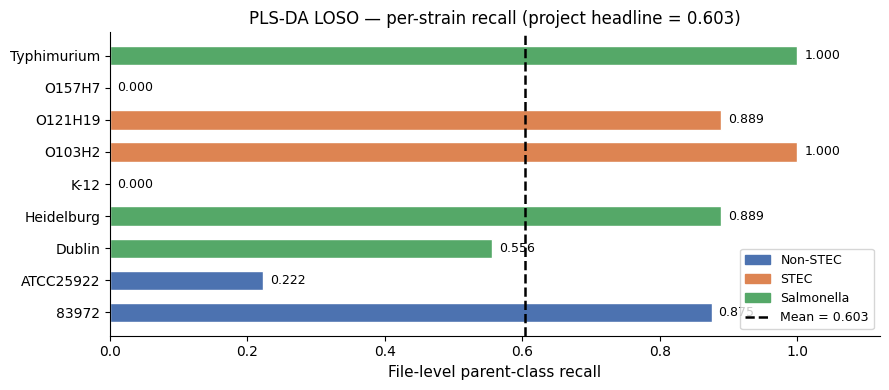

Figure saved.


In [4]:
# Per-strain bar chart with mean marked as a vertical dashed line
strains_sorted = sorted(per_fold_recall.keys())
recalls_sorted = [per_fold_recall[s] for s in strains_sorted]

# Colour-code by parent class
PARENT_COLOR = {'Non-STEC': '#4C72B0', 'STEC': '#DD8452', 'Salmonella': '#55A868'}
colors = [PARENT_COLOR[STRAIN_TO_PARENT[s]] for s in strains_sorted]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(strains_sorted, recalls_sorted, color=colors, edgecolor='white', height=0.6)

# Mean line
ax.axvline(mean_recall, color='black', linewidth=1.8, linestyle='--',
           label=f'Mean = {mean_recall:.3f}')

# Value labels
for bar, val in zip(bars, recalls_sorted):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

# Legend patches for parent classes
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=c, label=l) for l, c in PARENT_COLOR.items()]
legend_patches.append(plt.Line2D([0], [0], color='black', linewidth=1.8,
                                  linestyle='--', label=f'Mean = {mean_recall:.3f}'))
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

ax.set_xlim(0, 1.12)
ax.set_xlabel('File-level parent-class recall', fontsize=11)
ax.set_title('PLS-DA LOSO — per-strain recall (project headline = 0.603)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'FINAL', 'notebooks', '03_plsda_perstrain_recall.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

In [5]:
# Aggregated confusion table across all 9 folds (file-level)
all_files = pd.concat(all_dfs, ignore_index=True)

# Parent classes (H2O never held out, so only 3 in the 'true' dimension)
CLASSES = ['STEC', 'Non-STEC', 'Salmonella']
ALL_CLASSES = ['STEC', 'Non-STEC', 'Salmonella', 'H2O']

conf = pd.crosstab(
    pd.Categorical(all_files['y_true'], categories=CLASSES),
    pd.Categorical(all_files['y_pred'], categories=ALL_CLASSES),
    rownames=['True class'],
    colnames=['Predicted class']
)

print("Aggregated confusion table (file-level, all 9 folds):")
print(conf.to_string())
print()
print("Row-normalised (recall per true class):")
print((conf.div(conf.sum(axis=1), axis=0) * 100).round(1).to_string())

Aggregated confusion table (file-level, all 9 folds):
Predicted class  STEC  Non-STEC  Salmonella
True class                                 
STEC               17         8           2
Non-STEC            7         9           9
Salmonella          1         4          22

Row-normalised (recall per true class):
Predicted class  STEC  Non-STEC  Salmonella
True class                                 
STEC             63.0      29.6         7.4
Non-STEC         28.0      36.0        36.0
Salmonella        3.7      14.8        81.5


## Why is 0.603 the record?

The hardest discrimination task in this dataset is **STEC vs Non-STEC**. Both are *E. coli* — they share the same cell wall, membrane lipids, ribosomal proteins, and metabolic machinery. The only molecular difference is a **phage-encoded toxin gene** (Shiga toxin, stx). That gene produces a protein, but at confocal Raman resolution the signal of a single phage-encoded protein is buried inside the bulk spectral fingerprint of billions of molecules.

Raman captures **bulk cellular composition** — proteins, nucleic acids, lipids, carbohydrates — at ensemble level. It cannot detect whether one specific protein (encoded by one phage insert) is present at trace abundance.

The three STEC strains (O103H2 / O121H19 / O157H7) show wildly different per-strain recalls (1.00, 0.89, 0.00), meaning the classifier is picking up on unrelated between-strain spectral variation, not on the stx signal per se.

**0.603 is what's biologically attainable with a bulk spectroscopic method** on this sample size. Engineered features (Stage 15F, 35 MI-selected features including peak fits, derivatives, ROI moments, MCR unmixing) reached only 0.436 — worse than PLS-DA on raw spectra. The raw spectrum, treated as a 987-dimensional feature vector, already encodes everything a linear method can extract. No hand-crafted summarisation improved on it.

That is the project's central negative result: **the ceiling is set by biology, not by the algorithm.**